# Heart Disease Classification Using Decision Tree

### Importing nedded packages and libraries

In [1]:
import numpy as np
import pandas as pd
import seaborn as sns

### Reading dataset

In [5]:
df = pd.read_csv('dataset/HeartDisease.csv')
df

,age,sex,cp,trtbps,chol,fbs,restecg,thalachh,exng,oldpeak,slp,caa,thall,output
0,63,1,3,145,233,1,0,150,0,2.3,0,0,1,1
1,37,1,2,130,250,0,1,187,0,3.5,0,0,2,1
2,41,0,1,130,204,0,0,172,0,1.4,2,0,2,1
3,56,1,1,120,236,0,1,178,0,0.8,2,0,2,1
4,57,0,0,120,354,0,1,163,1,0.6,2,0,2,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
298,57,0,0,140,241,0,1,123,1,0.2,1,0,3,0
299,45,1,3,110,264,0,1,132,0,1.2,1,0,3,0
300,68,1,0,144,193,1,1,141,0,3.4,1,2,3,0
301,57,1,0,130,131,0,1,115,1,1.2,1,1,3,0


## Data cleaning 

#### Cecking for missing values 

In [10]:
df.isna().sum()

age         0
sex         0
cp          0
trtbps      0
chol        0
fbs         0
restecg     0
thalachh    0
exng        0
oldpeak     0
slp         0
caa         0
thall       0
output      0
dtype: int64

### Data dosn't have any missing value , Checking for duplicated

In [12]:
df.duplicated().sum()

np.int64(1)

### the Dataset has a duplicated value . Removing duplicate

In [13]:
df = df.drop_duplicates()

### A little analysis 

In [15]:
df.describe()

,age,sex,cp,trtbps,chol,fbs,restecg,thalachh,exng,oldpeak,slp,caa,thall,output
count,302.00000,302.000000,302.000000,302.000000,302.000000,302.000000,302.000000,302.000000,302.000000,302.000000,302.000000,302.000000,302.000000,302.000000
mean,54.42053,0.682119,0.963576,131.602649,246.500000,0.149007,0.526490,149.569536,0.327815,1.043046,1.397351,0.718543,2.314570,0.543046
std,9.04797,0.466426,1.032044,17.563394,51.753489,0.356686,0.526027,22.903527,0.470196,1.161452,0.616274,1.006748,0.613026,0.498970
min,29.00000,0.000000,0.000000,94.000000,126.000000,0.000000,0.000000,71.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,48.00000,0.000000,0.000000,120.000000,211.000000,0.000000,0.000000,133.250000,0.000000,0.000000,1.000000,0.000000,2.000000,0.000000
50%,55.50000,1.000000,1.000000,130.000000,240.500000,0.000000,1.000000,152.500000,0.000000,0.800000,1.000000,0.000000,2.000000,1.000000
75%,61.00000,1.000000,2.000000,140.000000,274.750000,0.000000,1.000000,166.000000,1.000000,1.600000,2.000000,1.000000,3.000000,1.000000
max,77.00000,1.000000,3.000000,200.000000,564.000000,1.000000,2.000000,202.000000,1.000000,6.200000,2.000000,4.000000,3.000000,1.000000


### The dataset is Ok and dosnt't have any outliers

In [16]:
df.info()

<class 'pandas.DataFrame'>
Index: 302 entries, 0 to 302
Data columns (total 14 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       302 non-null    int64  
 1   sex       302 non-null    int64  
 2   cp        302 non-null    int64  
 3   trtbps    302 non-null    int64  
 4   chol      302 non-null    int64  
 5   fbs       302 non-null    int64  
 6   restecg   302 non-null    int64  
 7   thalachh  302 non-null    int64  
 8   exng      302 non-null    int64  
 9   oldpeak   302 non-null    float64
 10  slp       302 non-null    int64  
 11  caa       302 non-null    int64  
 12  thall     302 non-null    int64  
 13  output    302 non-null    int64  
dtypes: float64(1), int64(13)
memory usage: 35.4 KB


In [37]:
df['output'].value_counts()

output
1    164
0    138
Name: count, dtype: int64

### Ploting features (EDA)

<Axes: xlabel='age', ylabel='Count'>

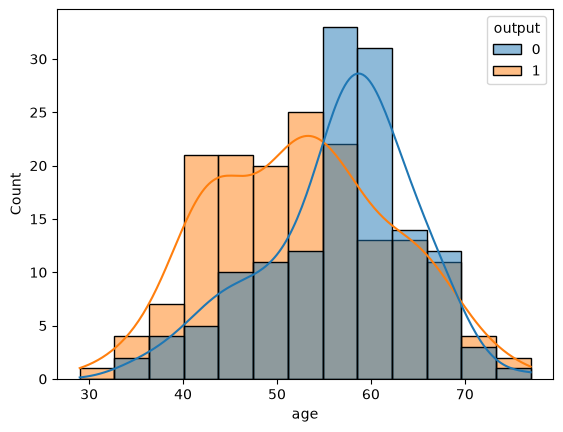

In [45]:
sns.histplot(data= df , x= df.age , hue= df.output , kde= True)

<Axes: xlabel='cp', ylabel='Count'>

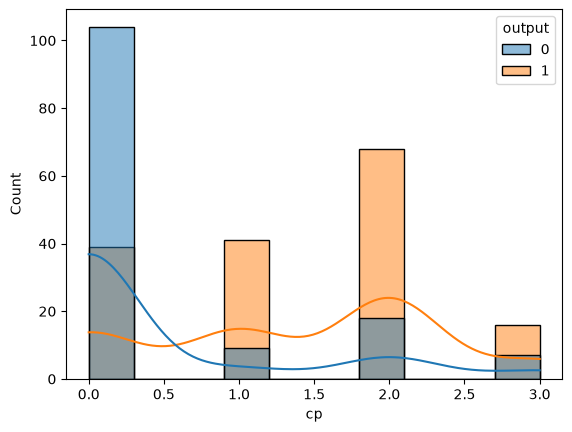

In [46]:
sns.histplot(data= df , x= df.cp , hue= df.output , kde= True)

<Axes: xlabel='sex', ylabel='Count'>

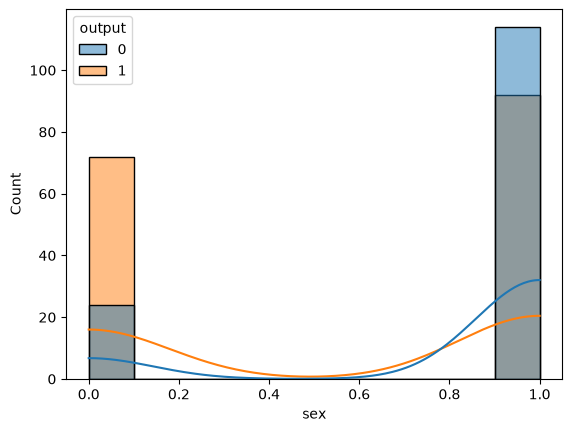

In [47]:
sns.histplot(data= df , x= df.sex , hue= df.output , kde= True)

<Axes: xlabel='trtbps', ylabel='Count'>

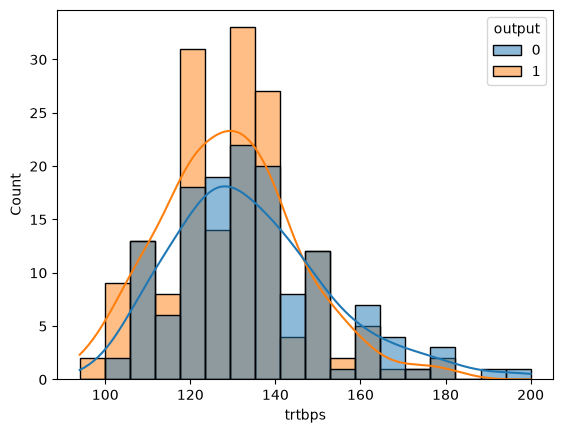

In [48]:
sns.histplot(data= df , x= df.trtbps , hue= df.output , kde= True)

<Axes: xlabel='chol', ylabel='Count'>

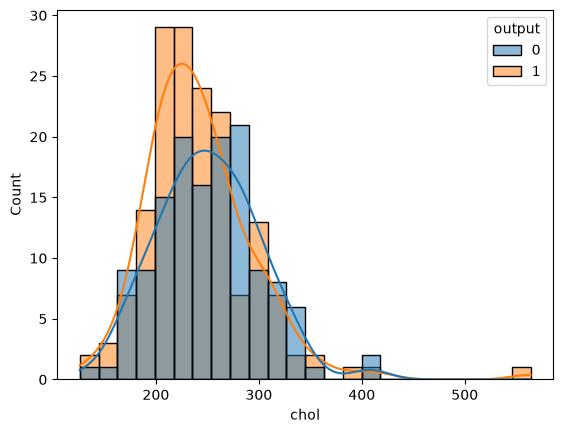

In [49]:
sns.histplot(data= df , x= df.chol , hue= df.output , kde= True)

<Axes: xlabel='fbs', ylabel='Count'>

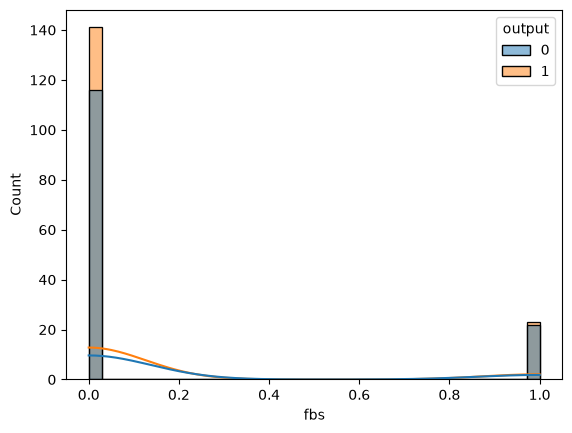

In [50]:
sns.histplot(data= df , x= df.fbs , hue= df.output , kde= True)

<Axes: xlabel='restecg', ylabel='Count'>

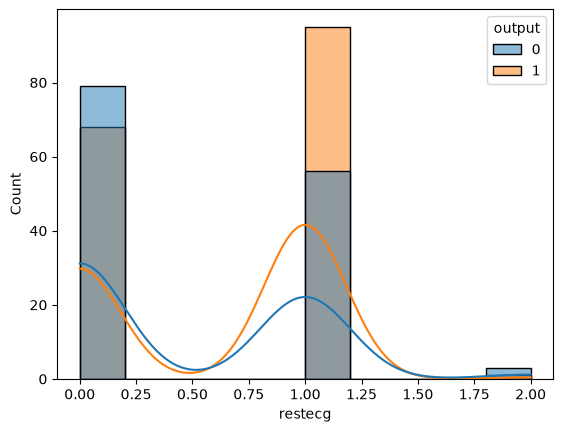

In [51]:
sns.histplot(data= df , x= df.restecg , hue= df.output , kde= True)

<Axes: xlabel='thalachh', ylabel='Count'>

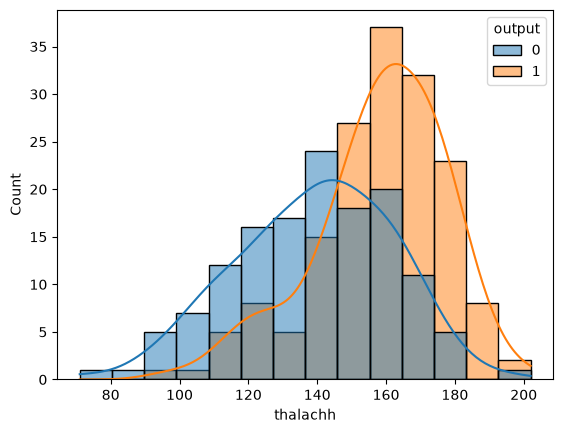

In [52]:
sns.histplot(data= df , x= df.thalachh , hue= df.output , kde= True)

<Axes: xlabel='exng', ylabel='Count'>

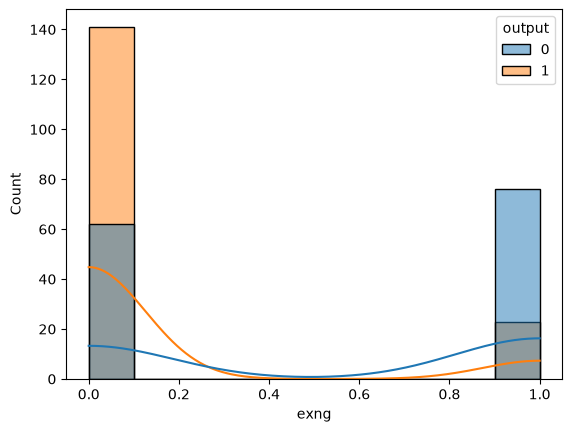

In [53]:
sns.histplot(data= df , x= df.exng , hue= df.output , kde= True)

<Axes: xlabel='oldpeak', ylabel='Count'>

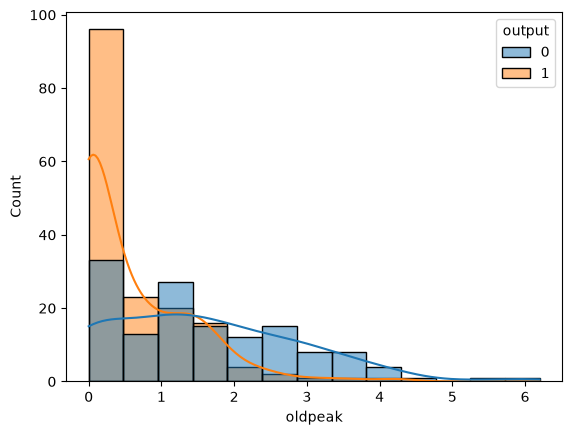

In [54]:
sns.histplot(data= df , x= df.oldpeak , hue= df.output , kde= True)

<Axes: xlabel='slp', ylabel='Count'>

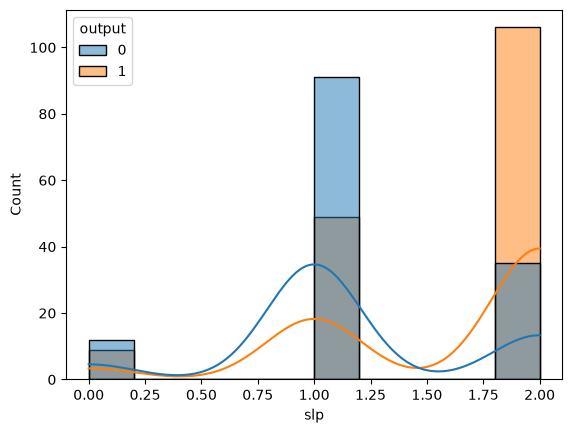

In [55]:
sns.histplot(data= df , x= df.slp , hue= df.output , kde= True)

<Axes: xlabel='caa', ylabel='Count'>

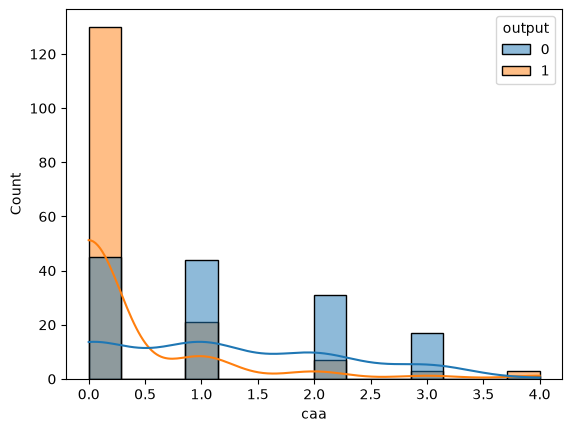

In [56]:
sns.histplot(data= df , x= df.caa , hue= df.output , kde= True)

<Axes: xlabel='thall', ylabel='Count'>

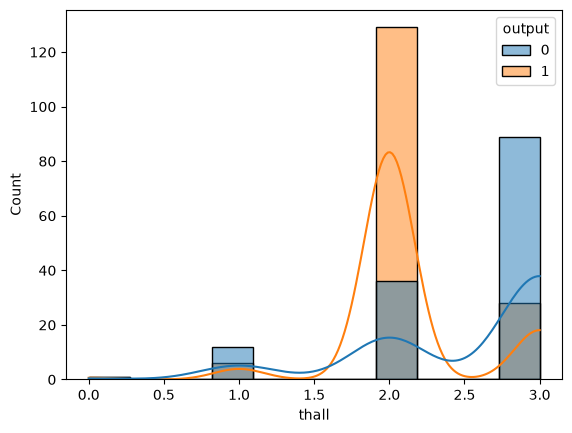

In [57]:
sns.histplot(data= df , x= df.thall , hue= df.output , kde= True)

In [2]:
sns.pairplot( df , 
              x_vars= ['age' ,
                        'sex' ,
                        'cp' , 
                        'trtbps' , 
                        'chol' , 
                        'fbs' , 
                        'restecg' , 
                        'thalachh' , 
                        'exng' , 
                        'oldpeak' , 
                        'slp' , 
                        'caa' , 
                        'thall'] , 
              y_vars= ['output'] ,
              hue= 'output'
)

NameError: name 'df' is not defined

### Preprocessing data

In [40]:
X_data = np.asanyarray(df[['age' , 'sex' , 'cp' , 'trtbps' , 'chol' , 'fbs' , 'restecg' , 'thalachh' , 'exng' , 'oldpeak' , 'slp' , 'caa' , 'thall']])
y_data = np.asanyarray(df['output'])

X_data[:5]

array([[ 63. ,   1. ,   3. , 145. , 233. ,   1. ,   0. , 150. ,   0. ,
          2.3,   0. ,   0. ,   1. ],
       [ 37. ,   1. ,   2. , 130. , 250. ,   0. ,   1. , 187. ,   0. ,
          3.5,   0. ,   0. ,   2. ],
       [ 41. ,   0. ,   1. , 130. , 204. ,   0. ,   0. , 172. ,   0. ,
          1.4,   2. ,   0. ,   2. ],
       [ 56. ,   1. ,   1. , 120. , 236. ,   0. ,   1. , 178. ,   0. ,
          0.8,   2. ,   0. ,   2. ],
       [ 57. ,   0. ,   0. , 120. , 354. ,   0. ,   1. , 163. ,   1. ,
          0.6,   2. ,   0. ,   2. ]])

In [41]:
y_data[:5]

array([1, 1, 1, 1, 1])

#### Data scaling and standardization

In [60]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_data_st = scaler.fit(X_data).transform(X_data)

#### Train/Test split

In [61]:
from sklearn.model_selection import train_test_split

X_train , X_test , y_train , y_test = train_test_split(X_data_st , y_data , test_size=0.2 , random_state= 42)
print('Train set shape : ' , X_train.shape , y_train.shape)
print('Test set shape : ' , X_test.shape , y_test.shape)

Train set shape :  (241, 13) (241,)
Test set shape :  (61, 13) (61,)


## Model Training

In [63]:
from sklearn.tree import DecisionTreeClassifier

disease_tree = DecisionTreeClassifier(criterion= 'entropy' , max_depth= 4)
disease_tree.fit(X_train , y_train)

,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.",'entropy'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",4
,"splitter splitter: {""best"", ""random""}, default=""best""The strategy used to choose the split at each node. Supportedstrategies are ""best"" to choose the best split and ""random"" to choosethe best random split.",'best'
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: int, float or {""sqrt"", ""log2""}, default=NoneThe number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... note:: The search for a split does not stop until at least one valid partition of the node samples is found, even if it requires to effectively inspect more than ``max_features`` features.",None
,"random_state random_state: int, RandomState instance or None, default=NoneControls the randomness of the estimator. The features are alwaysrandomly permuted at each split, even if ``splitter`` is set to``""best""``. When ``max_features < n_features``, the algorithm willselect ``max_features`` at random at each split before finding the bestsplit among them. But the best found split may vary across differentruns, even if ``max_features=n_features``. That is the case, if theimprovement of the criterion is identical for several splits and onesplit has to be selected at random. To obtain a deterministic behaviourduring fitting, ``random_state`` has to be fixed to an integer.See :term:`Glossary <random_state>` for details.",None
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow a tree with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsample

## Evaluation and Prediction

In [65]:
from sklearn import metrics

y_pred = disease_tree.predict(X_test)
print('Prediction Accuracy : %.2f' % metrics.accuracy_score(y_test , y_pred))

Prediction Accuracy : 0.82


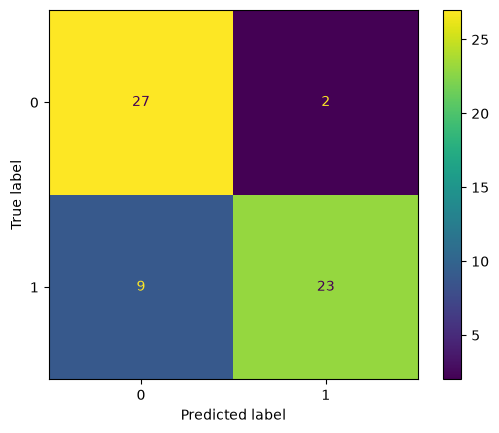

In [66]:
metrics.ConfusionMatrixDisplay.from_predictions(y_test , y_pred)

In [67]:
print(metrics.classification_report(y_test , y_pred))

              precision    recall  f1-score   support

           0       0.75      0.93      0.83        29
           1       0.92      0.72      0.81        32

    accuracy                           0.82        61
   macro avg       0.83      0.82      0.82        61
weighted avg       0.84      0.82      0.82        61

